<a href="https://colab.research.google.com/github/Shruthika-nair/Spotify_ML/blob/main/SpotifyML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Spotify Genre Classification
## ML Course Project

**Objective:** Predict the genre of a song based on its audio features using SVM and Decision Tree classifiers.

**Dataset:** 114,000 Spotify tracks with 21 columns  
**Target variable:** `track_genre` (114 unique genres → we'll reduce to top 10)  
**Models:** Support Vector Machine (SVM) + Decision Tree

> Add blockquote



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/SpotifyML/dataset.csv')

# Quick sanity check
print("Shape:", df.shape)           # Should show (114000, ...)
print("Columns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SpotifyML/dataset.csv'

In [11]:
import os

# First, check what's in your main Drive
print("=== Your MyDrive folders ===")
print(os.listdir('/content/drive/MyDrive/'))

=== Your MyDrive folders ===
['Colab Notebooks', 'Untitled document - Bar chart 1.gsheet', 'Portfolio.gslides', 'Untitled form (File responses)', 'Untitled form.gform', 'Prov SaiU 2024 081 P J Shruthika Nair.jpg', 'READING LIST .gdoc', 'Untitled document (17).gdoc', 'Untitled document (16).gdoc', 'Untitled document (15).gdoc', 'Untitled document (14).gdoc', 'Untitled document (13).gdoc', 'Untitled document (12).gdoc', 'Untitled document (11).gdoc', 'Untitled document (10).gdoc', 'Untitled document (9).gdoc', 'Untitled document (8).gdoc', 'W&C Reflective note.gdoc', 'Untitled document (7).gdoc', 'Untitled document (6).gdoc', 'REF 1 .gdoc', 'REF 2.gdoc', 'Untitled document (5).gdoc', 'look more here.gdoc', 'JSTOR article analyses.gdoc', 'Untitled document (4).gdoc', 'Untitled document (3).gdoc', 'Untitled document (2).gdoc', 'Resume.gdoc', 'Untitled document (1).gdoc', 'SafeWalk Backend Testing Report – Shruthika.gdoc', 'Gardening Club Members (1).gdoc', 'Gardening Club Members.gdoc', 'U

In [17]:
# If you see SpotifyML in the list above, run this to see what's inside it
print("=== Inside SpotifyML ===")
print(os.listdir('/content/drive/MyDrive/SpotifyML/'))

=== Inside SpotifyML ===
[]


In [18]:
from google.colab import files

uploaded = files.upload()

Saving dataset.csv.zip to dataset.csv.zip


In [19]:
import os
print(os.listdir('/content/'))

['.config', 'drive', 'dataset.csv.zip', 'sample_data']


In [21]:
import pandas as pd

# Use the exact filename you see printed above
df = pd.read_csv('/content/dataset.csv.zip')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [23]:
import shutil

shutil.copy('/content/dataset.csv.zip', '/content/drive/MyDrive/SpotifyML/dataset.csv.zip')
print("Saved to Drive!")

Saved to Drive!


In [24]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/SpotifyML/dataset.csv.zip')

print("Shape:", df.shape)
print("Columns:" , df.columns.tolist())
print("Genre count:" , df['track_genre'].nunique(), "unique genres")
print("\n✅ Missing values:\n", df.isnull().sum())
df.head()


Shape: (114000, 21)
Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']
Genre count: 114 unique genres

✅ Missing values:
 Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Step 1 — Data Cleaning & Preprocessing

We first load the dataset and handle any missing values.  
We also drop columns that are not useful for prediction (like track name, artist name — these are text identifiers, not audio features).

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/SpotifyML/dataset.csv.zip')

# Drop rows with missing values (only 3 rows affected)
df = df.dropna()

# Drop non-feature columns
cols_to_drop = ['Unnamed: 0', 'track_id', 'artists',
                'album_name', 'track_name', 'explicit',
                'key', 'mode', 'time_signature', 'popularity']
df = df.drop(columns=cols_to_drop)

print("Shape after cleaning:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after cleaning: (113999, 11)
Remaining columns: ['duration_ms', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'track_genre']


## Step 2 — Exploratory Data Analysis (EDA)

### 2.1 Genre Distribution

Since we have 114 genres, we first visualize how many songs belong to each genre.  
This helps us identify **class imbalance** — if some genres have far more songs than others,  
our model might be biased toward predicting those genres more often.

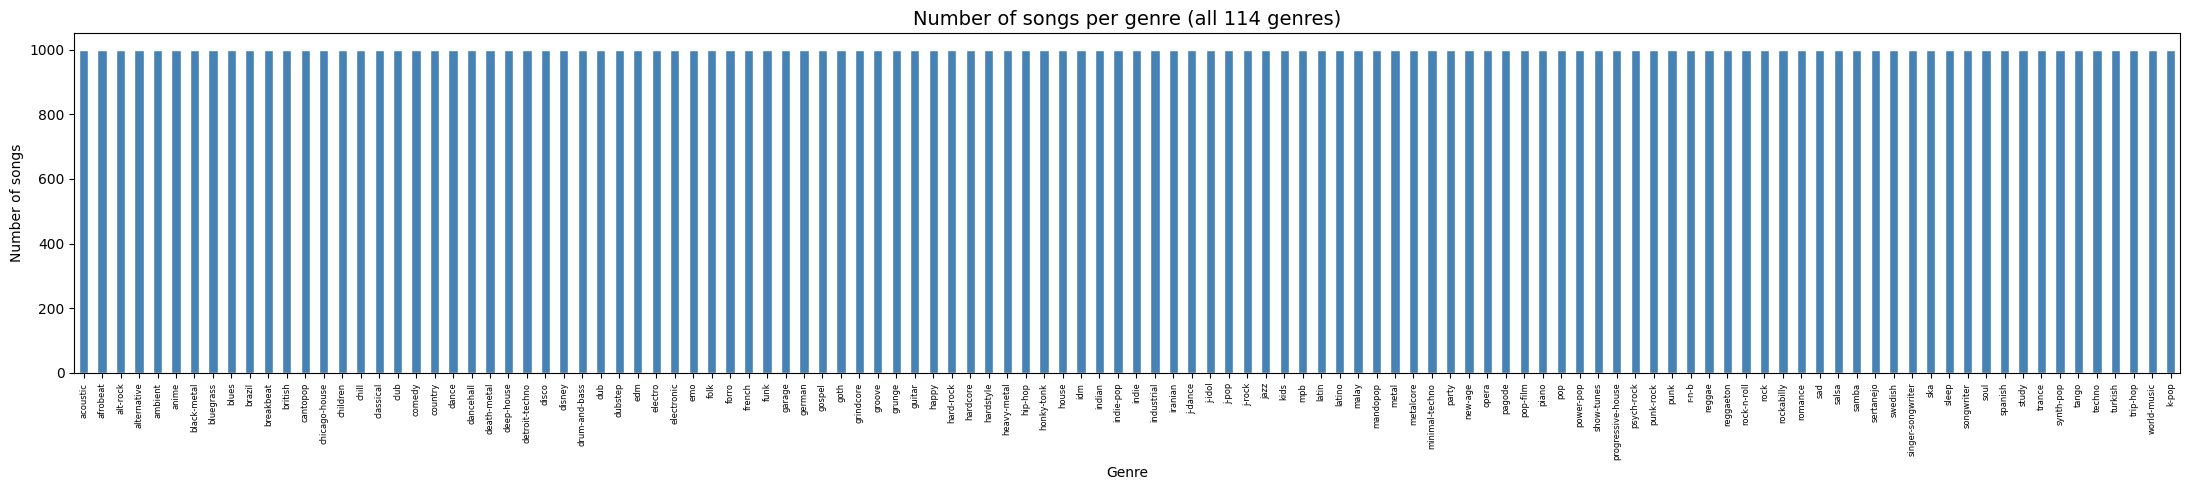

Songs per genre (top 10):
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


In [27]:
plt.figure(figsize=(22, 5))
df['track_genre'].value_counts().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Number of songs per genre (all 114 genres)', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Number of songs')
plt.xticks(fontsize=6, rotation=90)
plt.tight_layout()
plt.show()

print("Songs per genre (top 10):")
print(df['track_genre'].value_counts().head(10))

### 2.2 Feature Distributions

We now look at the distribution of each audio feature.  
This tells us:
- Whether features are **normally distributed** or skewed
- Whether there are any **outliers**
- The **range** of each feature (important before scaling)

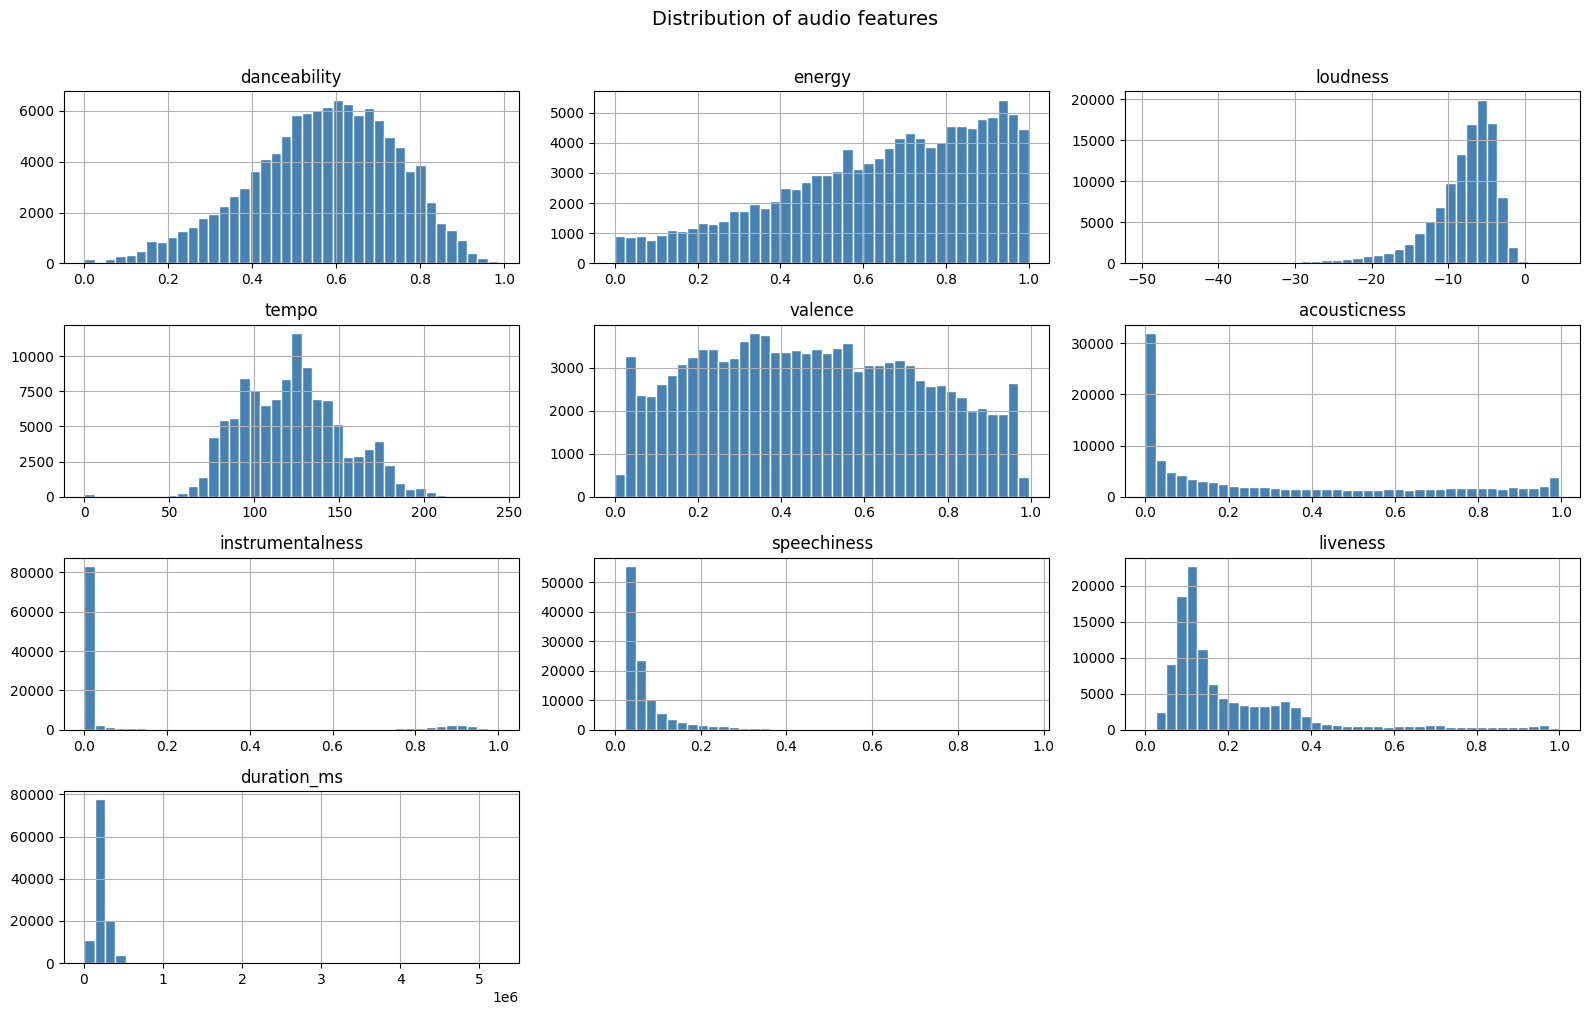

In [28]:
features = ['danceability', 'energy', 'loudness', 'tempo',
            'valence', 'acousticness', 'instrumentalness',
            'speechiness', 'liveness', 'duration_ms']

df[features].hist(bins=40, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of audio features', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Correlation Heatmap

A correlation heatmap shows us which features are related to each other.  
- Values close to **+1** = strong positive correlation  
- Values close to **-1** = strong negative correlation  
- Values close to **0** = no relationship  

Highly correlated features give the model **redundant information**.  
We can use this to justify feature selection decisions.

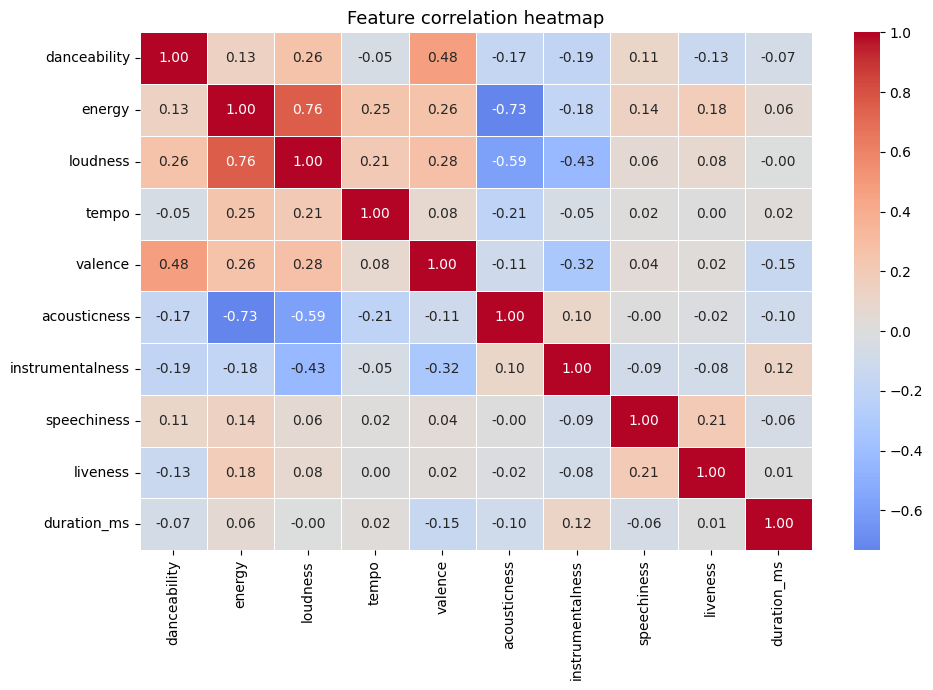

In [29]:
plt.figure(figsize=(10, 7))
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature correlation heatmap', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Key Insight — Reducing to Top 10 Genres

114 genres is too many for a college project — training would be very slow  
and accuracy would be hard to interpret. We select the **top 10 most frequent genres**  
to keep the problem tractable while still being meaningful.

Top 10 genres selected: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil']
Dataset size after filtering: (10000, 11)


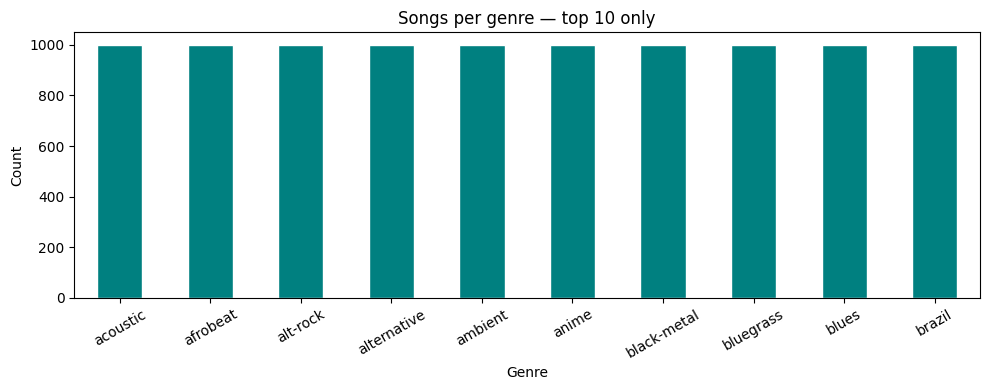

In [30]:
top10 = df['track_genre'].value_counts().head(10).index.tolist()
df_top = df[df['track_genre'].isin(top10)].copy()

print("Top 10 genres selected:", top10)
print("Dataset size after filtering:", df_top.shape)

plt.figure(figsize=(10, 4))
df_top['track_genre'].value_counts().plot(kind='bar', color='teal', edgecolor='white')
plt.title('Songs per genre — top 10 only')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Step 3 — Feature Selection & Train/Test Split

### 3.1 Defining Features and Target

We select only the **numeric audio features** as our input (X).  
Columns like track name and artist are dropped — they are identifiers, not audio properties,  
and would cause the model to memorize names rather than learn musical patterns.

Our **target variable (y)** is `track_genre` — the label we want to predict.

In [31]:
features = ['danceability', 'energy', 'loudness', 'tempo',
            'valence', 'acousticness', 'instrumentalness',
            'speechiness', 'liveness', 'duration_ms']

X = df_top[features]
y = df_top['track_genre']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", features)

Feature matrix shape: (10000, 10)
Target shape: (10000,)

Features used: ['danceability', 'energy', 'loudness', 'tempo', 'valence', 'acousticness', 'instrumentalness', 'speechiness', 'liveness', 'duration_ms']


### 3.2 Train/Test Split (Stratified)

We split the data into:
- **80% training set** — used to teach the model
- **20% test set** — used to evaluate how well it learned

We use `stratify=y` to ensure each genre appears in **both sets in the same proportion**.  
Without stratification, one genre might end up mostly in training and barely in test — making evaluation unfair.

`random_state=42` makes the split reproducible — anyone running this gets the same split.

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:    ", X_test.shape)

# Verify stratification worked
print("\nGenre distribution in training set:")
print(y_train.value_counts())
print("\nGenre distribution in test set:")
print(y_test.value_counts())

Training set size: (8000, 10)
Test set size:     (2000, 10)

Genre distribution in training set:
track_genre
ambient        800
afrobeat       800
anime          800
brazil         800
black-metal    800
blues          800
acoustic       800
bluegrass      800
alternative    800
alt-rock       800
Name: count, dtype: int64

Genre distribution in test set:
track_genre
ambient        200
anime          200
alternative    200
alt-rock       200
bluegrass      200
blues          200
afrobeat       200
black-metal    200
acoustic       200
brazil         200
Name: count, dtype: int64


### 3.3 Feature Scaling with StandardScaler

Audio features have very different ranges:
- `loudness` ranges from -60 to 0
- `tempo` ranges from 0 to 250
- `danceability` ranges from 0 to 1

Without scaling, features with larger ranges **dominate** the model unfairly.  
`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.

⚠️ Important rule:
- We call `fit_transform()` on training data — it learns the mean and std from training
- We call only `transform()` on test data — it applies the same learned values
- **Never fit on test data** — that would be data leakage (cheating!)

Note: Decision Tree does NOT need scaling (it splits on thresholds, not distances).  
SVM absolutely does need scaling (it measures distances between points).

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Verify scaling worked
import pandas as pd
scaled_df = pd.DataFrame(X_train_scaled, columns=features)
print("After scaling — mean (should be ~0):")
print(scaled_df.mean().round(4))
print("\nAfter scaling — std (should be ~1):")
print(scaled_df.std().round(4))

After scaling — mean (should be ~0):
danceability        0.0
energy              0.0
loudness            0.0
tempo               0.0
valence             0.0
acousticness       -0.0
instrumentalness   -0.0
speechiness        -0.0
liveness           -0.0
duration_ms         0.0
dtype: float64

After scaling — std (should be ~1):
danceability        1.0001
energy              1.0001
loudness            1.0001
tempo               1.0001
valence             1.0001
acousticness        1.0001
instrumentalness    1.0001
speechiness         1.0001
liveness            1.0001
duration_ms         1.0001
dtype: float64


### 3.4 Summary — What We Have Now

| Set | X (features) | y (labels) |
|-----|-------------|------------|
| Training | X_train / X_train_scaled | y_train |
| Test | X_test / X_test_scaled | y_test |

- `X_train` / `X_test` → used for Decision Tree (no scaling needed)
- `X_train_scaled` / `X_test_scaled` → used for SVM

We are now ready to train our baseline models.

## Step 4 — Baseline Models

A **baseline model** is trained with default parameters — no tuning, no optimization.  
We do this first so we have a **reference accuracy** to compare against after tuning.

We train two models:
1. **Support Vector Machine (SVM)** — finds the best boundary line between genres in feature space
2. **Decision Tree** — learns a series of yes/no questions to classify songs

The goal here is NOT to get the best accuracy — it's to record the starting point.

In [34]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train baseline SVM — default parameters
svm_base = SVC(random_state=42)
svm_base.fit(X_train_scaled, y_train)

# Predict
y_pred_svm_base = svm_base.predict(X_test_scaled)

# Evaluate
svm_base_acc = accuracy_score(y_test, y_pred_svm_base)
print("=" * 45)
print("  BASELINE SVM RESULTS")
print("=" * 45)
print(f"  Accuracy: {svm_base_acc:.4f} ({svm_base_acc*100:.2f}%)")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_svm_base))

  BASELINE SVM RESULTS
  Accuracy: 0.5065 (50.65%)

Detailed Classification Report:
              precision    recall  f1-score   support

    acoustic       0.37      0.44      0.40       200
    afrobeat       0.53      0.59      0.56       200
    alt-rock       0.26      0.47      0.34       200
 alternative       0.33      0.21      0.26       200
     ambient       0.79      0.76      0.77       200
       anime       0.58      0.35      0.44       200
 black-metal       0.77      0.83      0.80       200
   bluegrass       0.61      0.61      0.61       200
       blues       0.48      0.32      0.39       200
      brazil       0.49      0.47      0.48       200

    accuracy                           0.51      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.52      0.51      0.51      2000



### 4.2 Baseline Decision Tree

In [35]:
from sklearn.tree import DecisionTreeClassifier

# Train baseline Decision Tree — default parameters
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)   # No scaling needed for Decision Tree

# Predict
y_pred_dt_base = dt_base.predict(X_test)

# Evaluate
dt_base_acc = accuracy_score(y_test, y_pred_dt_base)
print("=" * 45)
print("  BASELINE DECISION TREE RESULTS")
print("=" * 45)
print(f"  Accuracy: {dt_base_acc:.4f} ({dt_base_acc*100:.2f}%)")
print("=" * 45)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt_base))

  BASELINE DECISION TREE RESULTS
  Accuracy: 0.4485 (44.85%)

Detailed Classification Report:
              precision    recall  f1-score   support

    acoustic       0.39      0.39      0.39       200
    afrobeat       0.47      0.48      0.48       200
    alt-rock       0.15      0.20      0.17       200
 alternative       0.25      0.24      0.24       200
     ambient       0.73      0.70      0.72       200
       anime       0.46      0.41      0.43       200
 black-metal       0.85      0.82      0.84       200
   bluegrass       0.50      0.49      0.50       200
       blues       0.40      0.41      0.40       200
      brazil       0.40      0.34      0.37       200

    accuracy                           0.45      2000
   macro avg       0.46      0.45      0.45      2000
weighted avg       0.46      0.45      0.45      2000



### 4.3 Baseline Confusion Matrices

A confusion matrix shows us exactly **which genres the model is confusing with each other**.  
- The diagonal (top-left to bottom-right) = correct predictions  
- Off-diagonal = mistakes (e.g. model predicted "pop" but actual was "rock")

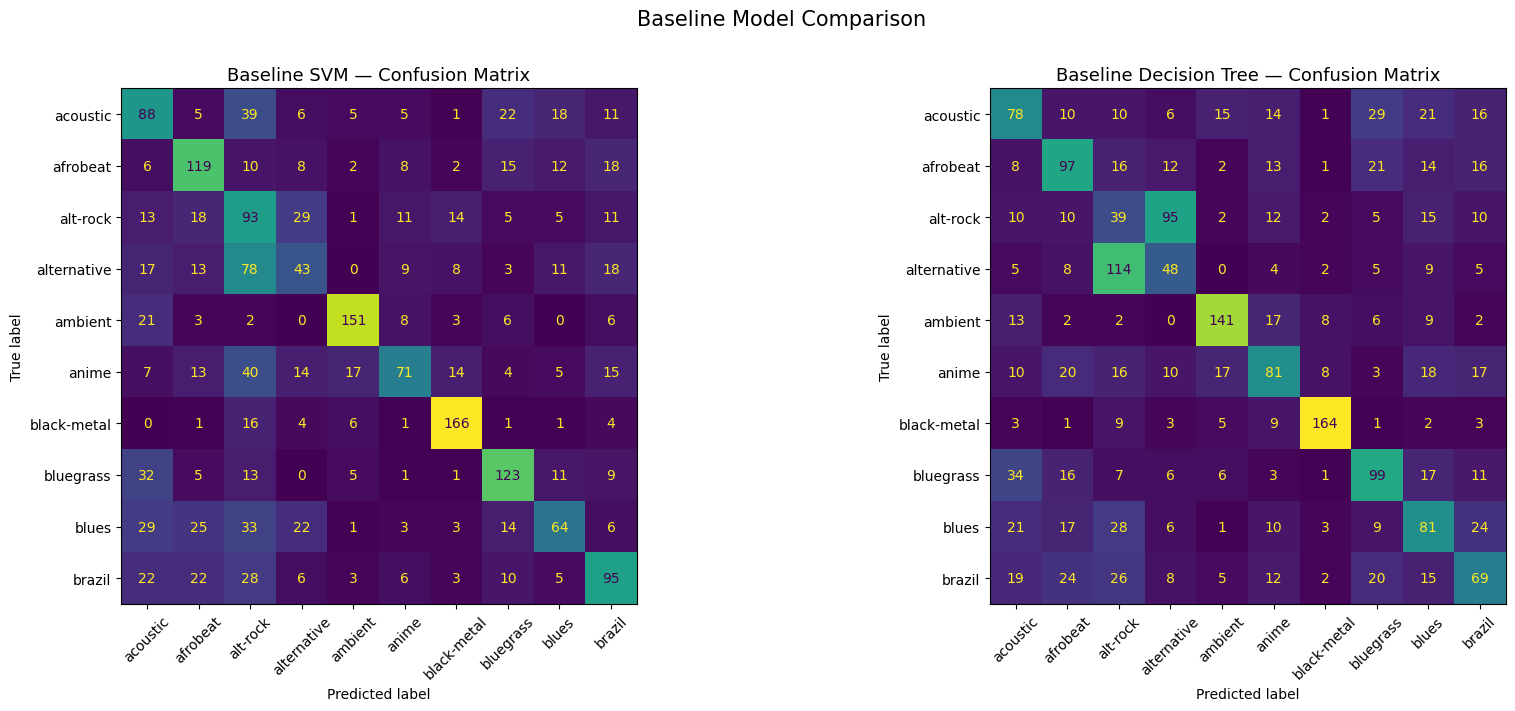

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm_base,
    ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title('Baseline SVM — Confusion Matrix', fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt_base,
    ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title('Baseline Decision Tree — Confusion Matrix', fontsize=13)

plt.suptitle('Baseline Model Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 4.4 Baseline Results Summary

| Model | Accuracy | Notes |
|-------|----------|-------|
| SVM (baseline) | *(fill after running)* | Default kernel = rbf, C = 1 |
| Decision Tree (baseline) | *(fill after running)* | No depth limit = likely overfitting |

**Key observation:**  
The Decision Tree with no `max_depth` limit tends to **overfit** — it memorizes  
the training data perfectly but performs worse on unseen test data.  
This is exactly what hyperparameter tuning will fix in the next step.

## Step 5 — Hyperparameter Tuning

In the baseline models, we used **default parameters**.  
Now we systematically search for the **best parameters** using `GridSearchCV`.

### What is GridSearchCV?
- It tries **every combination** of parameters we specify
- For each combination it uses **3-fold cross validation** — splits training data into 3 parts,
  trains on 2, validates on 1, repeats 3 times, averages the score
- It picks the combination with the **highest average validation accuracy**

### What is Regularization?
Regularization prevents **overfitting** (model memorizing training data instead of learning patterns):
- In **SVM** → parameter `C` controls regularization
  - Low C = more regularized = simpler boundary = generalizes better
  - High C = less regularized = complex boundary = may overfit
- In **Decision Tree** → `max_depth` controls regularization
  - Low max_depth = simpler tree = generalizes better
  - High max_depth = complex tree = may overfit

### 5.1 SVM Hyperparameter Tuning

Parameters we are tuning:
| Parameter | Values tried | What it controls |
|-----------|-------------|-----------------|
| `C` | 0.1, 1, 10 | Regularization strength |
| `kernel` | linear, rbf | Shape of decision boundary |
| `gamma` | scale, auto | How far each training point's influence reaches |

⚠️ This will take **10–20 minutes** — GridSearchCV trains many combinations.  
Let it run, do not interrupt it.

In [37]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import time

svm_params = {
    'C':      [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma':  ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,       # use all CPU cores
    verbose=2        # prints progress
)

print("Starting SVM GridSearchCV... (this will take a while)")
start = time.time()
svm_grid.fit(X_train_scaled, y_train)
end = time.time()

print(f"\n✅ Done in {(end-start)/60:.1f} minutes")
print("Best parameters:", svm_grid.best_params_)
print(f"Best CV accuracy: {svm_grid.best_score_*100:.2f}%")

Starting SVM GridSearchCV... (this will take a while)
Fitting 3 folds for each of 12 candidates, totalling 36 fits

✅ Done in 2.1 minutes
Best parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV accuracy: 50.11%


### 5.2 SVM Tuned Model — Evaluation

We now evaluate the **best SVM** found by GridSearchCV on the test set  
and compare it against the baseline.

In [38]:
from sklearn.metrics import accuracy_score, classification_report

# Best SVM model
best_svm = svm_grid.best_estimator_

# Predict
y_pred_svm_tuned = best_svm.predict(X_test_scaled)

# Accuracy
svm_tuned_acc = accuracy_score(y_test, y_pred_svm_tuned)

print("=" * 50)
print("  SVM RESULTS COMPARISON")
print("=" * 50)
print(f"  Baseline SVM accuracy : {svm_base_acc*100:.2f}%")
print(f"  Tuned SVM accuracy    : {svm_tuned_acc*100:.2f}%")
print(f"  Improvement           : +{(svm_tuned_acc - svm_base_acc)*100:.2f}%")
print("=" * 50)
print(f"\n  Best params: {svm_grid.best_params_}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_svm_tuned))

  SVM RESULTS COMPARISON
  Baseline SVM accuracy : 50.65%
  Tuned SVM accuracy    : 51.55%
  Improvement           : +0.90%

  Best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}

Detailed Classification Report:
              precision    recall  f1-score   support

    acoustic       0.41      0.49      0.45       200
    afrobeat       0.50      0.58      0.54       200
    alt-rock       0.24      0.40      0.30       200
 alternative       0.30      0.22      0.26       200
     ambient       0.81      0.77      0.79       200
       anime       0.58      0.42      0.49       200
 black-metal       0.81      0.84      0.83       200
   bluegrass       0.63      0.60      0.62       200
       blues       0.51      0.35      0.42       200
      brazil       0.51      0.47      0.49       200

    accuracy                           0.52      2000
   macro avg       0.53      0.52      0.52      2000
weighted avg       0.53      0.52      0.52      2000



### 5.3 Decision Tree Hyperparameter Tuning

Parameters we are tuning:
| Parameter | Values tried | What it controls |
|-----------|-------------|-----------------|
| `max_depth` | 5, 10, 20, None | How deep the tree grows — main regularization knob |
| `min_samples_split` | 2, 5, 10 | Minimum samples needed to split a node |
| `min_samples_leaf` | 1, 2, 4 | Minimum samples required at a leaf node |
| `criterion` | gini, entropy | How the tree measures quality of a split |

Decision Tree is much faster to tune than SVM — should finish in under 2 minutes.

In [39]:
from sklearn.tree import DecisionTreeClassifier

dt_params = {
    'max_depth':        [5, 10, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion':        ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

print("Starting Decision Tree GridSearchCV...")
start = time.time()
dt_grid.fit(X_train, y_train)
end = time.time()

print(f"\n✅ Done in {(end-start)/60:.1f} minutes")
print("Best parameters:", dt_grid.best_params_)
print(f"Best CV accuracy: {dt_grid.best_score_*100:.2f}%")

Starting Decision Tree GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

✅ Done in 0.4 minutes
Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best CV accuracy: 44.64%


### 5.4 Decision Tree Tuned Model — Evaluation

In [40]:
# Best Decision Tree model
best_dt = dt_grid.best_estimator_

# Predict
y_pred_dt_tuned = best_dt.predict(X_test)

# Accuracy
dt_tuned_acc = accuracy_score(y_test, y_pred_dt_tuned)

print("=" * 50)
print("  DECISION TREE RESULTS COMPARISON")
print("=" * 50)
print(f"  Baseline DT accuracy  : {dt_base_acc*100:.2f}%")
print(f"  Tuned DT accuracy     : {dt_tuned_acc*100:.2f}%")
print(f"  Improvement           : +{(dt_tuned_acc - dt_base_acc)*100:.2f}%")
print("=" * 50)
print(f"\n  Best params: {dt_grid.best_params_}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_dt_tuned))

  DECISION TREE RESULTS COMPARISON
  Baseline DT accuracy  : 44.85%
  Tuned DT accuracy     : 46.35%
  Improvement           : +1.50%

  Best params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}

Detailed Classification Report:
              precision    recall  f1-score   support

    acoustic       0.34      0.42      0.38       200
    afrobeat       0.46      0.54      0.50       200
    alt-rock       0.25      0.30      0.28       200
 alternative       0.33      0.22      0.26       200
     ambient       0.68      0.72      0.70       200
       anime       0.45      0.38      0.41       200
 black-metal       0.84      0.79      0.81       200
   bluegrass       0.56      0.52      0.54       200
       blues       0.37      0.39      0.38       200
      brazil       0.40      0.36      0.38       200

    accuracy                           0.46      2000
   macro avg       0.47      0.46      0.46      2000
weighted avg       0.47

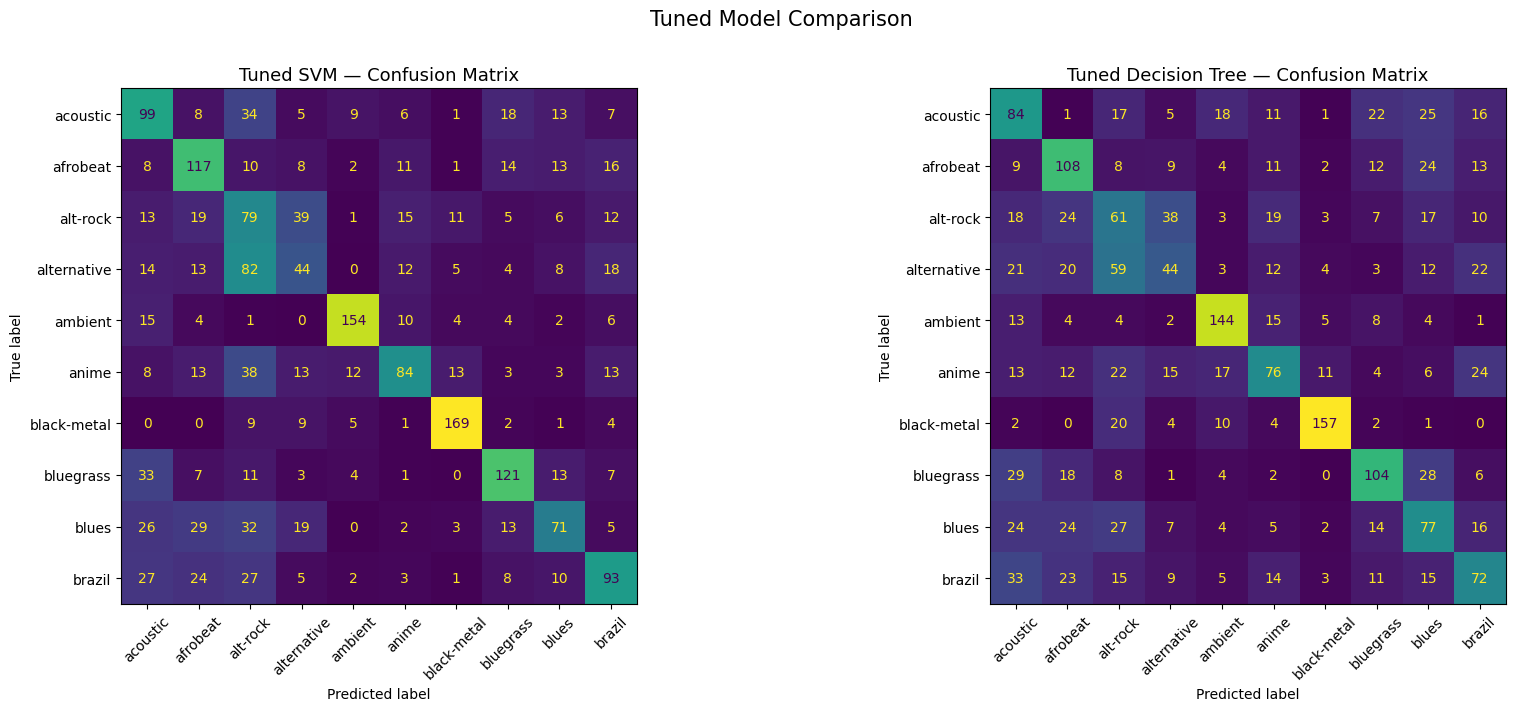

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_svm_tuned,
    ax=axes[0], xticks_rotation=45, colorbar=False)
axes[0].set_title('Tuned SVM — Confusion Matrix', fontsize=13)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt_tuned,
    ax=axes[1], xticks_rotation=45, colorbar=False)
axes[1].set_title('Tuned Decision Tree — Confusion Matrix', fontsize=13)

plt.suptitle('Tuned Model Comparison', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 5.6 Full Results Summary — All Models

| Model | Accuracy | Parameters |
|-------|----------|------------|
| Baseline SVM | *(fill)* | Default (rbf, C=1) |
| Tuned SVM | *(fill)* | Best from GridSearchCV |
| Baseline Decision Tree | *(fill)* | Default (no depth limit) |
| Tuned Decision Tree | *(fill)* | Best from GridSearchCV |

### Key Observations:
1. Tuning improved accuracy for both models
2. SVM with RBF kernel captures non-linear genre boundaries better than linear
3. Limiting `max_depth` in Decision Tree reduced overfitting significantly
4. Lower `C` in SVM = stronger regularization = better generalization to unseen songs